# **Creating a RAG with Local Ollama from Scratch [Countries Wiki Data]**





*This is a notebook for the Coursera course, Building and Deploying Generative AI Models from the specialization Generative AI Fundamentals by Alberta Machine Intelligence Institute (Amii) and is under an MIT License.*

Author: Anahita Doosti

Github Repository: [link](https://github.com/anna1995d/Building-and-Deploying-Generative-AI-Models-RAG-Notebooks)


---



In this notebook, we will use ollama to create a minimal RAG pipeline from scratch.


In [ ]:
# setting up command-line operation support
# xterm allows us to run shell commands directly in a Jupyter notebook
# Uncomment the appropriate section based on your setup

# GOOGLE COLAB
!pip install colab-xterm
%load_ext colabxterm

# JUPYTER LAB
# !pip install jupyterlab-ptyproc
# %load_ext notebook_xterm

We need Xterm so we can run the Ollama server in the background.

*The following sets up our GPU. Please ignore, if you are not using Vertex AI's Colab Enterprise.*

In [ ]:
# @title
# # @title GPU setup
# !sudo apt-get install lshw
# !curl https://ollama.ai/install.sh | sh
# !pip install ollama

# !echo 'debconf debconf/frontend select Noninteractive' | sudo debconf-set-selections
# !sudo apt-get update && sudo apt-get install -y cuda-drivers

# import os
# # Set LD_LIBRARY_PATH so the system NVIDIA library
# os.environ.update({'LD_LIBRARY_PATH': '/usr/lib64-nvidia'})

In [ ]:
%xterm
# Type in the following in the terminal:
# curl https://ollama.ai/install.sh | sh
# ollama serve &

*If at any later point you get the error message "Failed to connect to Ollama", rerun the cell calling xterm and run the serve command again.*

In [ ]:
# Load one LLM model and one embedding model
# Feel free to browse Ollama's available models at https://ollama.com/search
# The number after the colon represents the number of parameters. Adjust models based on your computational resources
!ollama pull gemma3:1b
!ollama pull embeddinggemma:300m

In [ ]:
# See all models available locally
!ollama list

In [ ]:
# install the ollama python library
!pip install ollama

# Load the RAG data

Our dataset consists of 10 documents, each containing cleaned text from a Wikipedia article on a different country. It also includes a (.csv) file containing question and answer pairs based only on these documents.

This dataset is a processed subset of a larger one that you can find linked below:


*Smith, N. A., Heilman, M., & Hwa, R. (2008, September) [[link]](https://https://www.kaggle.com/datasets/rtatman/questionanswer-dataset/data)*

In [ ]:
# Uncomment if you need to delete from another run
# !rm -rf small_country_qa_dataset

Using the the code below, you can download the dataset from the url and unzip it. The list `articles_filenames` contrains the path for each (.txt) article file and `qa_eval_filename` contains the path to the (.csv) Q&A file.

In [ ]:
# Download, and extract the database
import io       # For creating an in-memory binary stream
import zipfile  # For handling zip files
import requests # For loading the file from the web

# The database is a .zip file containing .txt articles
url = "https://drive.google.com/uc?export=view&id=1jSukgKpxy0bVMJqtmpfrPFMu-gT-MeTm"

try:
    db_zip = requests.get(url, timeout=60)
    db_zip.raise_for_status() # fail fast on bad status

    filenames = list()

    with zipfile.ZipFile(io.BytesIO(db_zip.content)) as zf:
        filenames = zf.namelist()
        zf.extractall() # extract all files in the local directory

    print(f"Downloaded {len(filenames)} files.")

except requests.exceptions.RequestException as e:
    print(f"Error downloading the file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Separate eval data and articles
articles_filenames = filenames[-10:]
qa_eval_filename =  filenames[1]

Given the file name, the next function will return the file header (containing the article subject) and the list of all sentences in the file.
This easy approach will be our initial chunking strategy.

In [ ]:
def extract_sentences(filename):
    with open(filename, 'r', encoding="utf-8") as file:
        subject = file.readline().rstrip('\n\r') # separate the file header
        file_content = file.read().rstrip('\n\r').replace('\n', '').split('.') # read the rest of the file

        return subject, file_content

# Vector Storage Implementation

We're storing vectors in memory. Each chunk of text is turned into a vector using an Ollama embedding model and then stored in ```vector_db```. For this simple pipeline, we'll treat each sentence as a "chunk".

The result of `ollama.embed()` has many different attributes suchs as model, but we only care about the embedding itself which is the only element in the `embeddings` attribute, which is a list itself.

In [ ]:
import ollama
import numpy as np

# Change the names based on the model you pull earlier
embedding_model = "embeddinggemma:300m"
llm_model = "gemma3:1b"

vector_db = []

def chunk_to_vector_embedding(chunk):
    embedding = ollama.embed(model=embedding_model, input=chunk).embeddings[0] # get the vector only
    return embedding

Let's see how this works with an example!

In [ ]:
test_vector = chunk_to_vector_embedding("Hello world! This is a test!")

In [ ]:
print(f'length: {len(test_vector)}, embedding: {test_vector}')

Now, we use ```chunk_to_vector_embedding``` to go through each chunk and add it to the vector database.

We want to keep track of a few things for each chunk in addition to the embedding vector: the text content, the source article, and the article subject. We use a Python dataclass to define a `Chunk` object that has these attributes.

***The next cell might take a few minutes to run. If it's taking too long for you, reduce the size of your dataset.***

In [ ]:
from dataclasses import dataclass

@dataclass
class Chunk:
    content: str
    embedding: list[float]
    source: str | None
    subject: str

# Extract sentences from every file and populate the vector database
# If it's too slow for you to process every file, you can limit the number of
# files by changing the range in the for loop or using a subset of all filenames
# You can even run the code with only one article
for filename in articles_filenames:
    subject, file_content = extract_sentences(filename)

    for chunk in file_content:
        if chunk.strip() == '':
            # Skip if the chunk is empty
            continue
        chunk += '.' # (optional) add a period to the end of the chunk

        # Get the vector embedding
        embedding = chunk_to_vector_embedding(chunk)

        vector_db.append(
            Chunk(
                content=chunk,
                embedding=embedding,
                source=filename,
                subject=subject
            )
        )
    print(f"Processed {filename} and added embeddings to the database.")

Let's check the size of our vector database and look a random entry.

In [ ]:
# Database length
print(f'Database size: {len(vector_db)}\n')
# Let's look at a random entry in the database
r = 150 # You can try out other entries
print(f'Entry {r}:')
print(f'Content: {vector_db[r].content}')
print(f'Source: {vector_db[r].source}')
print(f'Subject: {vector_db[r].subject}')
print(f'Embedding length: {len(vector_db[r].embedding)}')
print(f'Embedding: {vector_db[r].embedding}')

# Retrieval

Now we need a similarity metric between two vectors, so we can retrieve the top N similar chunks for the query.
We'll use cosine similarity here.

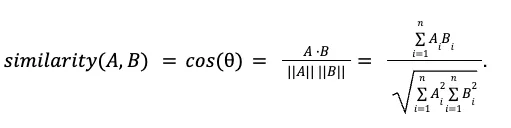

In [ ]:
def cosine_similarity(a, b):
  dot_product = np.dot(a, b)
  norm_a = np.linalg.norm(a)
  norm_b = np.linalg.norm(b)
  return dot_product / (norm_a * norm_b)

Now, we use this metric to implement our retrieval function.

In [ ]:
def retrieve(query, top_n=5):
  # Embed the query into a vector
  query_vector = ollama.embed(model="embeddinggemma:300m", input=query).embeddings[0]

  # List for (chunk, similarity) tuples
  similarities = list()

  # Populate the list
  for chunk in vector_db:
    sim = cosine_similarity(query_vector, chunk.embedding)
    similarities.append((chunk, sim))

  # Sort similarities
  # key=lambda x: x[1] means the list is sorted based on x[1] for each x
  # In Python, "lambda" is an "anonymous function", meaning it doesn't need to be named
  # The syntax is "lambda [input]:[output]"
  similarities.sort(key=lambda x: x[1], reverse=True) # descending

  # Return the top N chunks
  return similarities[:top_n]

# Generation

The next function receives a question called `input_query` and `top_n`, and performs the following steps:

*   Uses the `retrieve` function above to retrieve the top N most similar chunks.
*   Concatenate their text in `context_string`.
*   Defines a prompt that instructs the LLM to use the context to answer the query question.
*   Uses `ollama.generate()` for text completion to ask the LLM to continute the prompt by answering the question.

*By passing `verbose=True` to the function, it will print the reponse as well as the retrieved context.*

In [ ]:
def answer_query(input_query, top_n=5, verbose=False):
    # Retrieve the top 5 relevant chunks
    retrieved_context = retrieve(query=input_query, top_n=top_n)

    # joining context chunks in one string
    context_string = '\n'.join([x[0].content for x in retrieved_context])

    instruction_prompt = "You are a helpful question-answering chatbot.\n" \
                          "Use only the following pieces of context to answer the question.\n" \
                          "If you don't know the answer, just say that you don't know and don't make up any new information.\n\n" \
                          "Here is the context: \n" \
                          f"{context_string}\n\n" \
                          "Question: " \
                          f"{input_query}\n\n" \
                          "Answer:"

    response = ollama.generate(
        model=llm_model,
        prompt=instruction_prompt,
    )

    if verbose:
        print("Chatbot response:")
        print(response.response)
        print("------------------------------------------")
        print(f'Retrieved context:')
        for n, x in enumerate(retrieved_context):
            # x[0] is chunk, x[1] is similarity
            print(f'* {n+1} \t similarity: {x[1]:.2f} - Subject: {x[0].subject} - {x[0].content}')
    else:
        return response.response, retrieved_context

Let's try it!

In [ ]:
answer_query("What is the life expectancy for men in Finland?", top_n=5, verbose=True)

In [ ]:
# Uncomment and run if you want open up space by deleting ollama
# !rm -rf /usr/local/bin/ollama

*MIT License Copyright (c) 2025 Alberta Machine Intelligence Institute (amii)*